In [44]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os

In [45]:
df_applications = pd.read_csv('./data/cleaned_data/applications.csv')
df_voyage_schedule = pd.read_csv('./data/cleaned_data/voyage_schedule.csv')

In [46]:
# Examine the shape and data types of both DataFrames
print("df_applications shape:", df_applications.shape)
print("df_applications data types:\n", df_applications.dtypes)
print("\ndf_voyage_schedule shape:", df_voyage_schedule.shape)
print("df_voyage_schedule data types:\n", df_voyage_schedule.dtypes)

# Inspect the 'voyage(from voyage signup)' column in df_applications
print("\nUnique values in voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].unique())
print("Value counts for 'voyage_from_voyage_signups)':\n", df_applications['voyage_from_voyage_signups'].value_counts())
print("Missing values in 'voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].isnull().sum())

# Identify the relevant columns in df_voyage_schedule
print("\nRelevant columns in df_voyage_schedule (Voyage numbers and dates): 'Name', 'Start Date', 'End Date'")

# Analyze the relationship between the voyage numbers in both DataFrames
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("\nCommon voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

df_applications shape: (10600, 27)
df_applications data types:
 unique_id                      object
timestamp                      object
subscription_status            object
subscription_status_dt         object
voyage_role                    object
gender                         object
country_code                   object
goal                           object
source                         object
source_other                   object
country_name_from_country      object
voyage_from_voyage_signups     object
application_age_in_days       float64
application_day_of_week        object
day_of_week_no                float64
no_voyages_started            float64
application_date               object
application_year              float64
updated_voyage_number          object
updated_voyage_start_date      object
application_month             float64
application_week              float64
subscription_status_year      float64
subscription_status_month     float64
subscription_status_week

In [47]:
# Analyze the 'Voyage (from Voyage Signups)' column for inconsistencies and patterns
# Check for multiple voyage numbers separated by commas
df_applications['voyage_from_voyage_signups'].str.contains(',').sum()

# Analyze the frequency of 'V??' and its potential meaning
print("Frequency of 'V??':", df_applications['voyage_from_voyage_signups'].str.contains('V\?\?').sum())

# Further exploration:
# Analyze the relationship between the voyage numbers and the 'Application Date' column
# Check if there are any specific voyage numbers associated with missing values
# Analyze the 'Voyage Role' and 'Goal' columns in relation to the voyage numbers

Frequency of 'V??': 146


In [48]:
# Analyze the relationship between the voyage numbers in both DataFrames
# Check if there are any common voyage numbers, and if the voyage numbers in df_applications match the voyage numbers in df_voyage_schedule
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("Common voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

# Explore the potential meaning of 'V??'
# Check if it's associated with a specific application date or other attributes
df_v_question_mark = df_applications[df_applications['voyage_from_voyage_signups'].str.contains('V\?\?', na=False)]
print("\nRows with 'V??':\n", df_v_question_mark.head())

# Check if 'V??' is related to the application date
print("\nApplication dates associated with 'V??':\n", df_v_question_mark['application_date'].value_counts())

Common voyage numbers between df_applications and df_voyage_schedule: {'V35', 'V43', 'V54', 'V38', 'V46', 'V33', 'V40', 'V47', 'V52', 'V55', 'V44', 'V37', 'V42', 'V50', 'V41', 'V32', 'V36', 'V39', 'V48', 'V51', 'V53', 'V34', 'V49', 'V45'}

Rows with 'V??':
                             unique_id         timestamp subscription_status  \
24   7be16909aa5092c16b8aca8e2b670969   2025-02-26 1:49              Active   
27   2edcefff8314a00296bf4adc1aa25ed0  2025-02-25 15:57              Active   
30   9f4e32681a0ab7d9e534a276d13c8c65  2025-02-25 13:48              Active   
55   0b79c89ebb33b3b73e8818a7340a516b  2025-02-23 14:53              Active   
119  020d590f46116b3351b0624996b4ac43  2025-02-13 21:37              Active   

    subscription_status_dt   voyage_role  gender country_code  \
24              2025-02-26     Developer  FEMALE           IN   
27              2025-02-25     Developer  FEMALE           BR   
30              2025-02-25     Developer    MALE           US   
55     

In [49]:
df_expanded_applications = pd.DataFrame()

for index, row in df_applications.iterrows():
  voyage_str = row['voyage_from_voyage_signups']
  if isinstance(voyage_str, str) and ',' in voyage_str:
    voyages = [v.strip() for v in voyage_str.split(',')]
    for voyage in voyages:
      new_row = row.copy()
      new_row['voyage_from_voyage_signups'] = voyage
      df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([new_row])], ignore_index=True)
  else:
    df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([row])], ignore_index=True)

In [50]:
voyage_date_dict = {}
for index, row in df_voyage_schedule.iterrows():
  voyage_number = row['Name']
  start_date = row['Start Date']
  if pd.notna(start_date):
    voyage_date_dict[voyage_number] = start_date

In [51]:
# Convert date fields to datetime
df_expanded_applications['application_date'] = pd.to_datetime(df_applications['application_date'], errors='coerce')
df_voyage_schedule['Start Date'] = pd.to_datetime(df_voyage_schedule['Start Date'], errors='coerce')

# Prepare target columns
df_expanded_applications['updated_voyage_number'] = None
df_expanded_applications['updated_voyage_number'] = None

# Sort voyages by Start Date
df_voyage_schedule = df_voyage_schedule.sort_values('Start Date')

# Function to get the next voyage
def find_next_voyage(application_date):
    if pd.isna(application_date):
        return None, None
    future_voyages = df_voyage_schedule[df_voyage_schedule['Start Date'] > application_date]
    if future_voyages.empty:
        return None, None
    next_voyage = future_voyages.iloc[1]  # Pick the first available voyage
    return next_voyage['Name'], next_voyage['Start Date'] 

# Apply update for 'V??'
mask = df_expanded_applications['voyage_from_voyage_signups'] == 'V??'
for idx in df_expanded_applications[mask].index:
    app_date = df_expanded_applications.at[idx, 'application_date']
    name, start_date = find_next_voyage(app_date)
    df_expanded_applications.at[idx, 'updated_voyage_number'] = name
    df_expanded_applications.at[idx, 'updated_voyage_start_date'] = start_date

# Regex to match 'V##' where ## is numeric (2 or 3 digits)
regex_mask = df_expanded_applications['voyage_from_voyage_signups'].fillna('').str.match(r'^V\d{2,3}$')

# Apply update for 'V##'
for idx in df_expanded_applications[regex_mask].index:
    voyage_name = df_expanded_applications.at[idx, 'voyage_from_voyage_signups']
    voyage_row = df_voyage_schedule[df_voyage_schedule['Name'] == voyage_name]
    if not voyage_row.empty:
        df_expanded_applications.at[idx, 'updated_voyage_start_date'] = voyage_row.iloc[0]['Start Date']
        df_expanded_applications.at[idx, 'updated_voyage_number'] = voyage_name


In [52]:
df_expanded_applications['updated_voyage_number'].fillna('')
df_expanded_applications['updated_voyage_start_date'].fillna('')

0         
1         
2         
3         
4         
        ..
10595     
10596     
10597     
10598     
10599     
Name: updated_voyage_start_date, Length: 10600, dtype: object

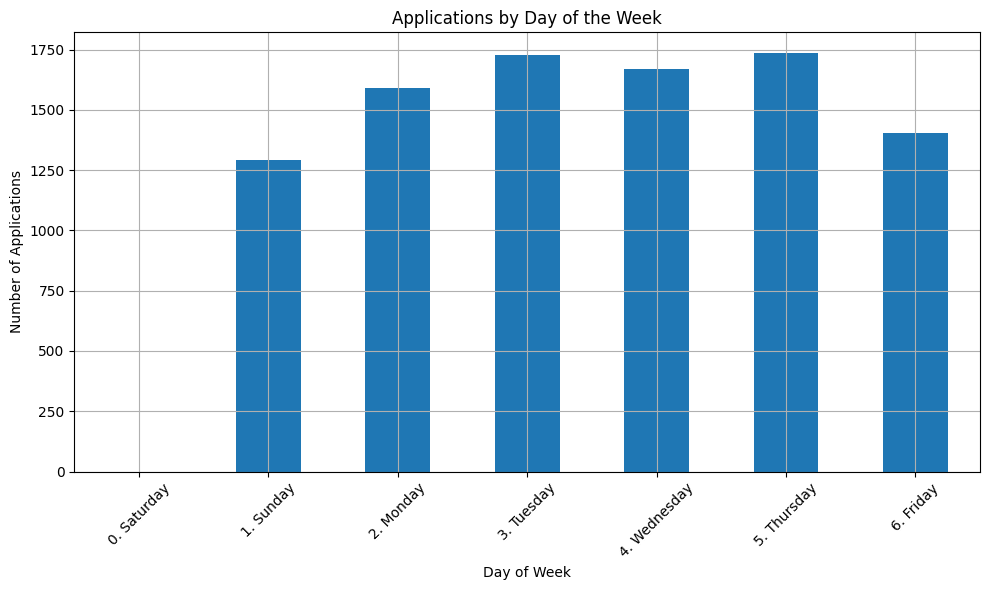

In [53]:
# Prepare data for weekly trends by 'Application Day-of-Week'
day_order = ['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday']

# Count number of applications per day of week
weekly_counts = df_expanded_applications['application_day_of_week'].value_counts().reindex(day_order)

# Plot
plt.figure(figsize=(10, 6))
weekly_counts.plot(kind='bar')
plt.title("Applications by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

<Figure size 2000x1500 with 0 Axes>

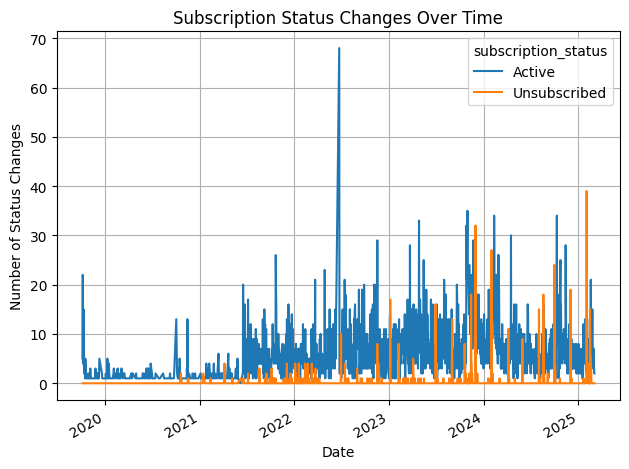

In [54]:
# Convert 'Subscription Status DT' to datetime
df_expanded_applications['subscription_status_dt'] = pd.to_datetime(df_expanded_applications['subscription_status_dt'], errors='coerce')

# Count subscription status changes over time
subscription_time_series = (
    df_expanded_applications.groupby(['subscription_status_dt', 'subscription_status'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot
plt.figure(figsize=(20, 15))
subscription_time_series.plot()
plt.title("Subscription Status Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Status Changes")
plt.grid(True)
plt.tight_layout()
plt.show()

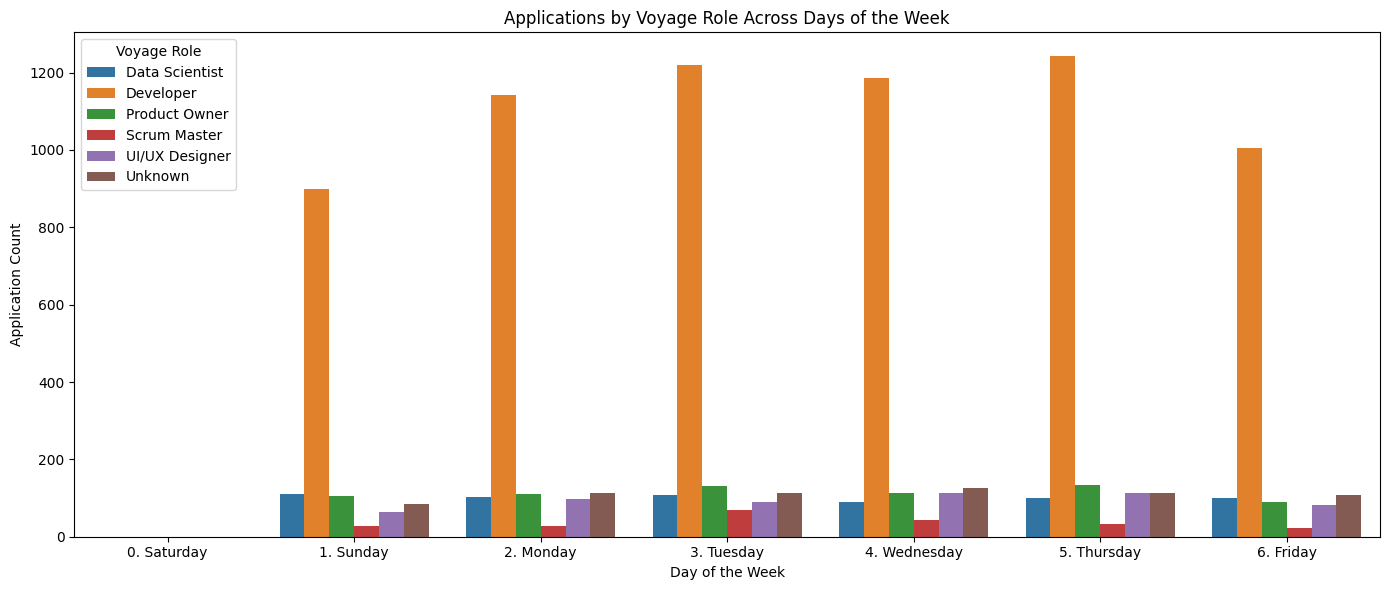

In [55]:
import seaborn as sns
# Filter relevant columns
role_goal_df = df_expanded_applications[['voyage_role', 'goal', 'application_day_of_week']].dropna()

# Count of applications by Role and Day of Week
role_day_counts = (
    role_goal_df.groupby(['application_day_of_week', 'voyage_role'])
    .size()
    .reset_index(name='Count')
)

# Sort days
role_day_counts['application_day_of_week'] = pd.Categorical(
    role_day_counts['application_day_of_week'],
    categories=['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday'],
    ordered=True
)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=role_day_counts,
    x='application_day_of_week',
    y='Count',
    hue='voyage_role'
)
plt.title("Applications by Voyage Role Across Days of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

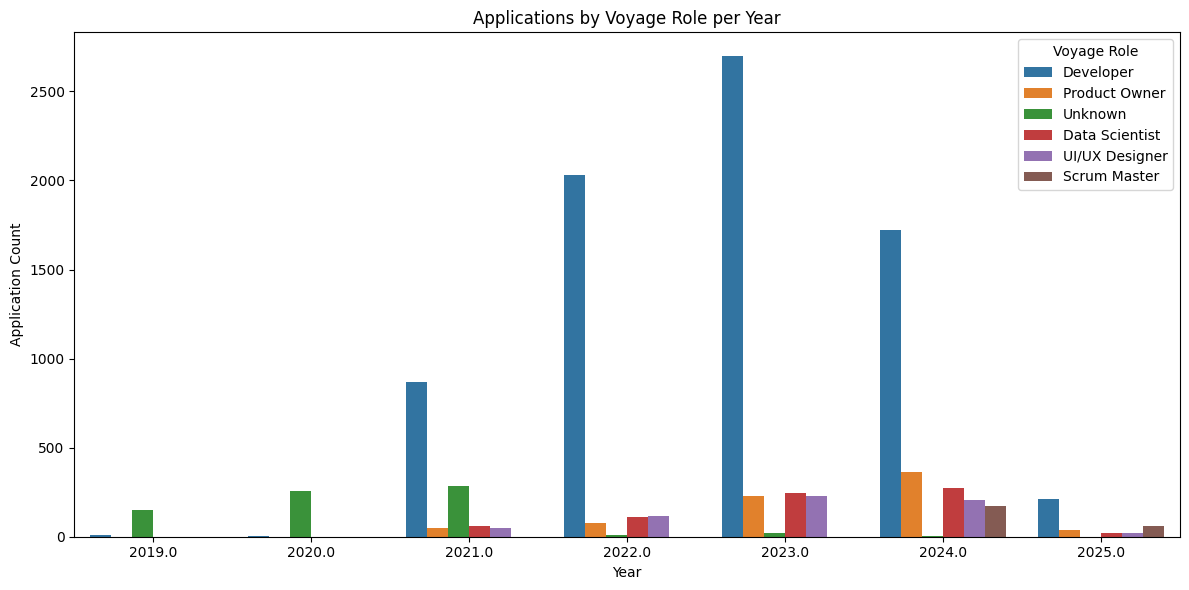

In [56]:
# Convert 'Timestamp' to datetime
df_expanded_applications['timestamp'] = pd.to_datetime(df_expanded_applications['timestamp'], errors='coerce')

# Extract year from timestamp
df_expanded_applications['application_year'] = df_expanded_applications['timestamp'].dt.year

# Group by year and Voyage Role
year_role_counts = (
    df_expanded_applications.groupby(['application_year', 'voyage_role'])
    .size()
    .reset_index(name='Count')
    .dropna()
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=year_role_counts,
    x='application_year',
    y='Count',
    hue='voyage_role'
)
plt.title("Applications by Voyage Role per Year")
plt.xlabel("Year")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

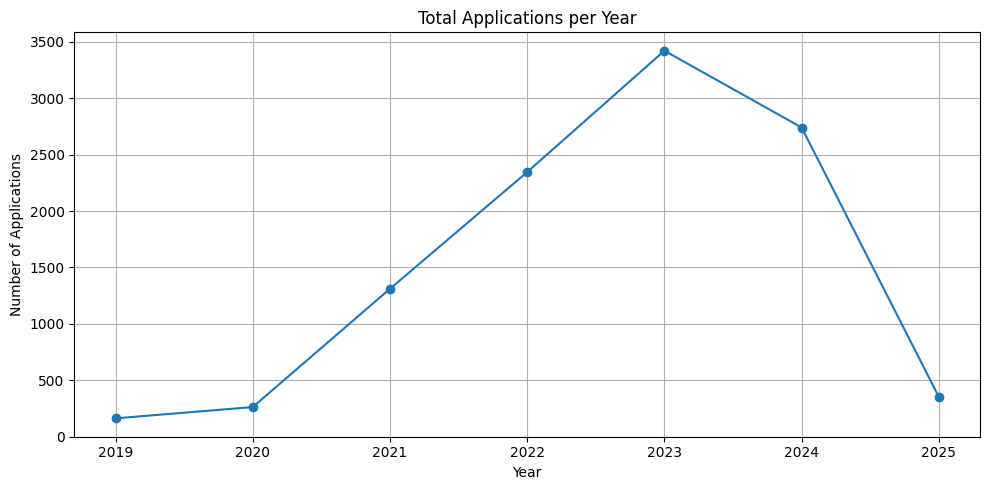

In [57]:
yearly_trend = df_expanded_applications['application_year'].value_counts().sort_index()

# Plot line trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')
plt.title("Total Applications per Year")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

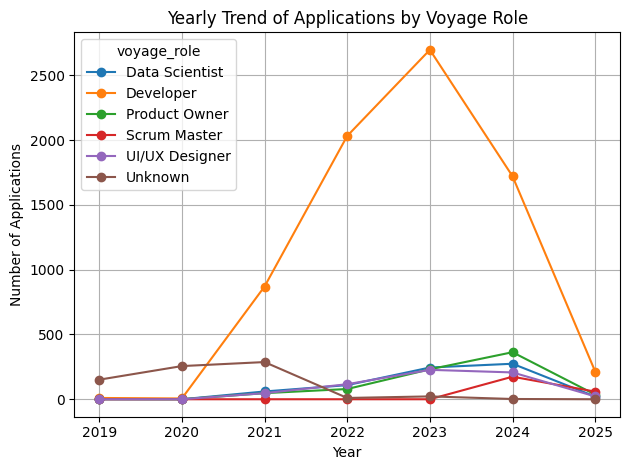

<Figure size 1400x600 with 0 Axes>

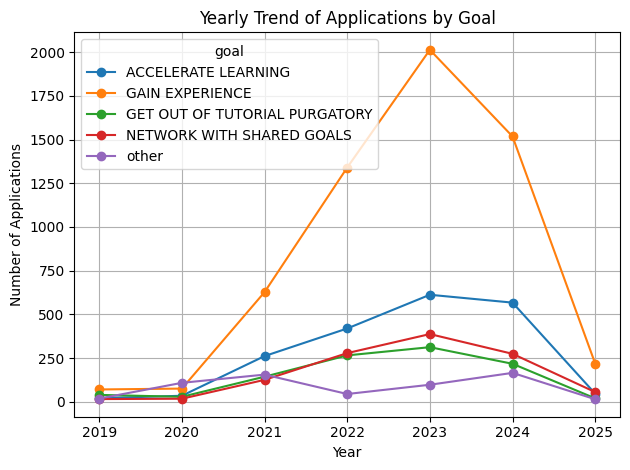

In [58]:
# Group by year and voyage role
yearly_role_trend = (
    df_expanded_applications.groupby(['application_year', 'voyage_role'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Group by year and goal
yearly_goal_trend = (
    df_expanded_applications.groupby(['application_year', 'goal'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot role trend
plt.figure(figsize=(12, 5))
yearly_role_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Voyage Role")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot goal trend
plt.figure(figsize=(14, 6))
yearly_goal_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Goal")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

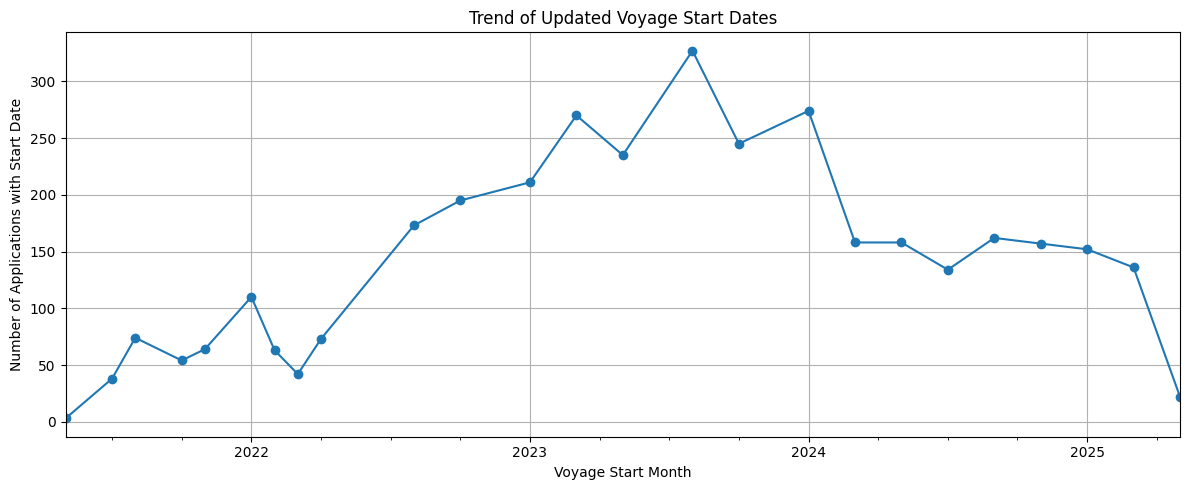

In [59]:
import warnings
warnings.filterwarnings('ignore')
# Convert 'Updated Voyage Start Date' to datetime
df_expanded_applications['updated_voyage_start_date'] = pd.to_datetime(df_expanded_applications['updated_voyage_start_date'], errors='coerce')

# Drop rows with no start date
voyage_start_df = df_expanded_applications.dropna(subset=['updated_voyage_start_date'])

# Group by month-year for trend
voyage_start_df['voyage_start_month'] = voyage_start_df['updated_voyage_start_date'].dt.to_period('M')

# Count of voyages starting each month
voyage_start_trend = (
    voyage_start_df.groupby('voyage_start_month')
    .size()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
voyage_start_trend.plot(marker='o')
plt.title("Trend of Updated Voyage Start Dates")
plt.xlabel("Voyage Start Month")
plt.ylabel("Number of Applications with Start Date")
# add a legend for goal and role 
plt.grid(True)
plt.tight_layout()
plt.show()

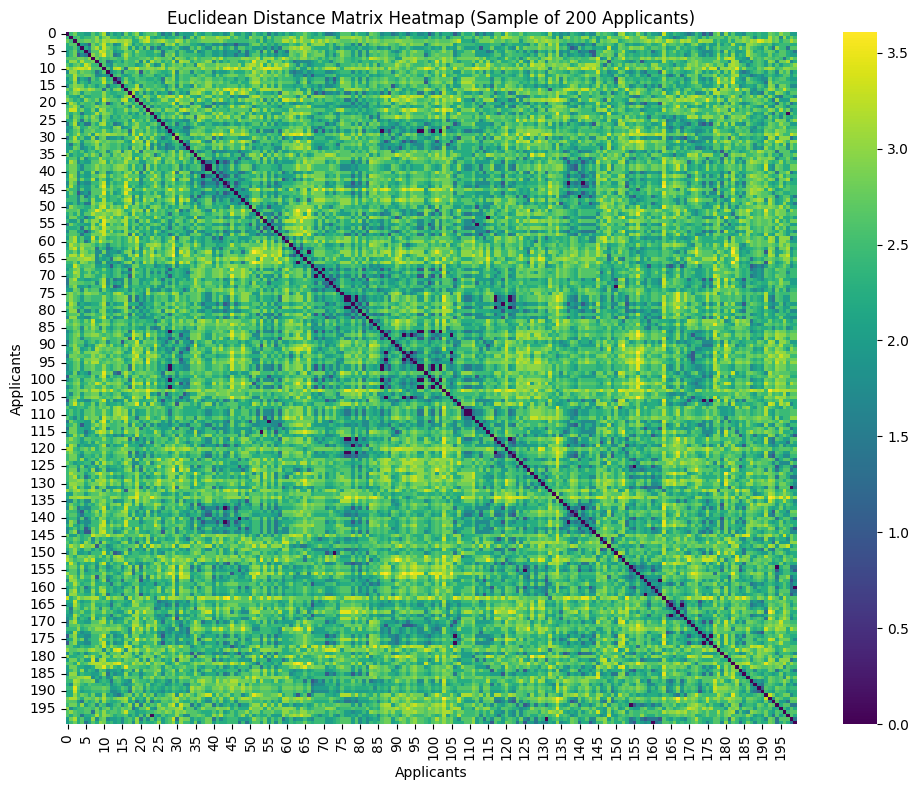


Cross-Validation Accuracy Scores: [nan nan nan nan nan]
Mean CV Accuracy: nan

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.69      0.95      0.80      1414
           1       0.56      0.13      0.22       706

    accuracy                           0.68      2120
   macro avg       0.62      0.54      0.51      2120
weighted avg       0.64      0.68      0.60      2120


Classification Report (Extrapolation):
              precision    recall  f1-score   support

           0       0.68      0.95      0.79      1414
           1       0.53      0.12      0.20       706

    accuracy                           0.67      2120
   macro avg       0.61      0.53      0.50      2120
weighted avg       0.63      0.67      0.60      2120



In [63]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from scipy.spatial import distance
from sklearn.decomposition import PCA
from category_encoders import BinaryEncoder


# Feature Engineering
# df_expanded_applications['updated_voyage_start_date'] = pd.to_datetime(df_expanded_applications['updated_voyage_start_date'], errors='coerce')
# df_expanded_applications['will_join_voyage'] = df_expanded_applications['updated_voyage_start_date'].notna().astype(int)

# Filter relevant features
features = [
    'voyage_role', 'gender', 'goal', 'source',
    'subscription_status', 'application_age_in_days', 'application_day_of_week'
]
df_expanded_applications = df_expanded_applications[features + ['will_join_voyage']].dropna()

X = df_expanded_applications[features]
y = df_expanded_applications['will_join_voyage']

# Preprocessing
categorical = ['voyage_role', 'gender', 'goal', 'source','subscription_status', 'application_day_of_week']
numerical = ['application_age_in_days']

preprocessor = ColumnTransformer([
    ('cat', BinaryEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit preprocessing on full dataset for clustering insight
X_processed = preprocessor.fit_transform(X)

# Compute distance matrix for clustering-based grouping
sample_size = 200
X_sample = X_processed[:sample_size].toarray() if hasattr(X_processed[:sample_size], 'toarray') else X_processed[:sample_size]
distance_matrix = distance.cdist(X_sample, X_sample, metric='euclidean')

# Heatmap of distance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='viridis')
plt.title("Euclidean Distance Matrix Heatmap (Sample of 200 Applicants)")
plt.xlabel("Applicants")
plt.ylabel("Applicants")
plt.tight_layout()
plt.show()

# Split dataset: Interapolation (60%), Extrapolation (20%)
X_intera, X_extra, y_intera, y_extra = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Split dataset: train (75%), test (15%)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.25, stratify=y_intera, random_state=42)

# Ridge Regression with Cross-Validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), cv=5)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', ridge)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Test set
y_test_pred = model.predict(X_test) > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Evaluate on Extrapolation set
y_extra_pred = model.predict(X_extra) > 0.5
print("\nClassification Report (Extrapolation):")
print(classification_report(y_extra , y_extra_pred))

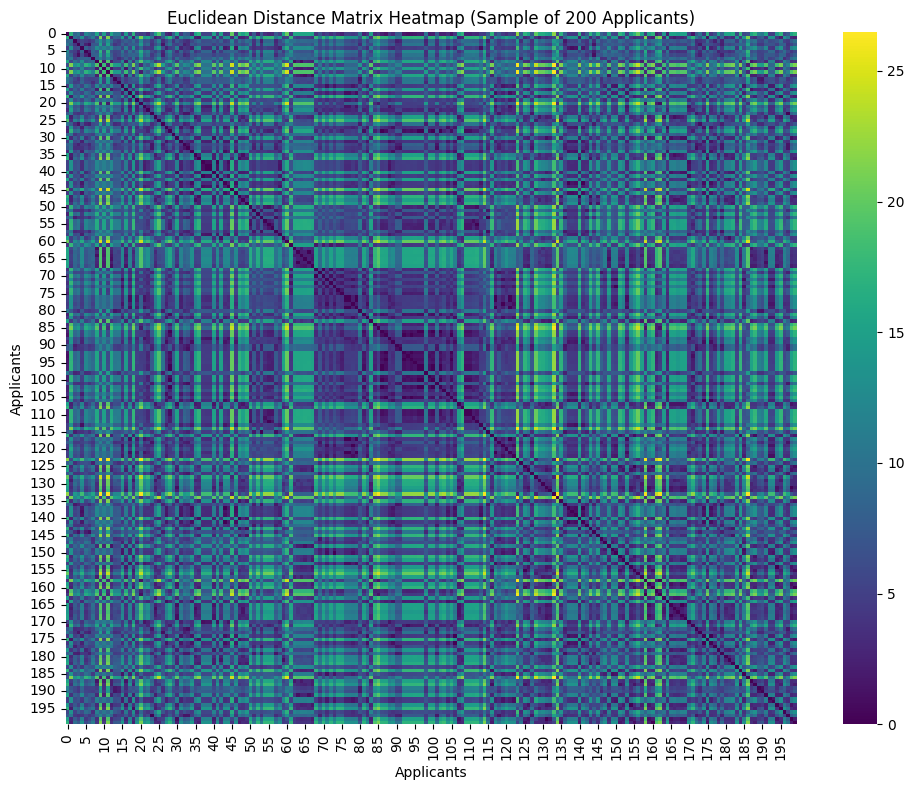


Cross-Validation Accuracy Scores: [nan nan nan nan nan]
Mean CV Accuracy: nan

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.67      0.96      0.79      1414
           1       0.46      0.06      0.11       706

    accuracy                           0.66      2120
   macro avg       0.57      0.51      0.45      2120
weighted avg       0.60      0.66      0.57      2120


Classification Report (Extrapolation):
              precision    recall  f1-score   support

           0       0.67      0.98      0.80      1414
           1       0.53      0.06      0.10       706

    accuracy                           0.67      2120
   macro avg       0.60      0.52      0.45      2120
weighted avg       0.63      0.67      0.57      2120



In [65]:
from sklearn.preprocessing import OrdinalEncoder
features = [
    'voyage_role', 'gender', 'goal', 'source',
    'subscription_status', 'application_age_in_days', 'application_day_of_week'
]
df_expanded_applications = df_expanded_applications[features + ['will_join_voyage']].dropna()

X = df_expanded_applications[features]
y = df_expanded_applications['will_join_voyage']

# Preprocessing
categorical = ['voyage_role', 'gender', 'goal', 'source','subscription_status', 'application_day_of_week']
numerical = ['application_age_in_days']

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit preprocessing on full dataset for clustering insight
X_processed = preprocessor.fit_transform(X)

# Compute distance matrix for clustering-based grouping
sample_size = 200
X_sample = X_processed[:sample_size].toarray() if hasattr(X_processed[:sample_size], 'toarray') else X_processed[:sample_size]
distance_matrix = distance.cdist(X_sample, X_sample, metric='euclidean')

# Heatmap of distance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='viridis')
plt.title("Euclidean Distance Matrix Heatmap (Sample of 200 Applicants)")
plt.xlabel("Applicants")
plt.ylabel("Applicants")
plt.tight_layout()
plt.show()

# Split dataset: Interapolation (60%), Extrapolation (20%)
X_intera, X_extra, y_intera, y_extra = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Split dataset: train (75%), test (15%)
X_train, X_test, y_train, y_test = train_test_split(X_intera, y_intera, test_size=0.25, stratify=y_intera, random_state=42)

# Ridge Regression with Cross-Validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), cv=5)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', ridge)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Test set
y_test_pred = model.predict(X_test) > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Evaluate on Extrapolation set
y_extra_pred = model.predict(X_extra) > 0.5
print("\nClassification Report (Extrapolation):")
print(classification_report(y_extra , y_extra_pred))